# 2 april: TOZ differentiaalvergelijkingen met SymPy

Gegeven is de volgende constructie:

```{figure-start} ./toz_data/constructie.svg
:align: center
:class: sticky-margins
:source: https://github.com/Structural-Mechanics-CEG/mechanics-figures-source/tree/main/toz_sympy
:number:
```

$$EI\left(x\right) = 64000 \, \rm{kNm}^2$$

```{figure-end}
```

Bekijk je eigen indiening in [WebLab](https://weblab.tudelft.nl/ctb1310/2025-2026/assignment/166848/info).

::::{question} Opgave
:variant: multiple-select
:admonition:
:columns: 1 2 3 4
:class: exercise
:showanswer:
:nocaption:
Welke voorwaarden gelden op $x=0$?

Voor ... kan je elke waarde ongelijk aan $0$ invullen die je van tevoren kan bepalen enkel op basis van het model op $x=0$.
---
[x] $w_1\left(0\right) =0 $
[ ] $\varphi_1\left(0\right) =0 $
[x] $M_1\left(0\right) =0 $
[ ] $V_1\left(0\right) =0 $
[ ] $w_1\left(0\right) = ... $
[ ] $\varphi_1\left(0\right) = ... $
[ ] $M_1\left(0\right) = ... $
[ ] $V_1\left(0\right) = ... $

---

::::

::::{question} Opgave
:variant: multiple-select
:admonition:
:columns: 1 1 2 2
:showanswer:
:class: exercise
:nocaption:
Welke voorwaarden gelden op $x=4$?

Voor ... kan je elke waarde ongelijk aan $0$ invullen die je van tevoren kan bepalen enkel op basis van het model op $x=4$.
---
[x] $w_1\left(4\right) = w_2\left(4\right) \ne 0$
[ ] $\varphi_1\left(4\right) = \varphi_2\left(4\right) \ne 0 $
[ ] $M_1\left(4\right) = M_2\left(4\right) \ne 0 $
[ ] $V_1\left(4\right) = V_2\left(4\right) \ne 0$
[ ] $w_1\left(4\right) = w_2\left(4\right) = 0 $
[ ] $\varphi_1\left(4\right) = \varphi_2\left(4\right) = 0$
[x] $M_1\left(4\right) = M_2\left(4\right) = 0 $
[ ] $V_1\left(4\right) = V_2\left(4\right) = 0 $
[ ] $M_1\left(4\right) - M_2\left(4\right) + \text{...} = 0$
[x] $V_1\left(4\right) - V_2\left(4\right) + \text{...} = 0$

---

::::

::::{question} Opgave
:variant: multiple-select
:admonition:
:columns: 1 1 2 2
:class: exercise
:showanswer:
:nocaption:
Welke voorwaarden gelden op $x=9$?

Voor ... kan je elke waarde ongelijk aan $0$ invullen die je van tevoren kan bepalen enkel op basis van het model op $x=9$.
---
[ ] $w_1\left(9\right) = w_2\left(9\right) \ne 0$
[x] $\varphi_1\left(9\right) = \varphi_2\left(9\right) \ne 0 $
[x] $M_1\left(9\right) = M_2\left(9\right) \ne 0 $
[ ] $V_1\left(9\right) = V_2\left(9\right) \ne 0$
[x] $w_1\left(9\right) = w_2\left(9\right) = 0 $
[ ] $\varphi_1\left(9\right) = \varphi_2\left(9\right) = 0$
[ ] $M_1\left(9\right) = M_2\left(9\right) = 0 $
[ ] $V_1\left(9\right) = V_2\left(9\right) = 0 $
[ ] $M_1\left(9\right) - M_2\left(9\right) + \text{...} = 0$
[ ] $V_1\left(9\right) - V_2\left(9\right) + \text{...} = 0$

---

::::

::::{question} Opgave
:variant: multiple-select
:admonition:
:columns: 1 2 3 4
:showanswer:
:class: exercise
:nocaption:
Welke voorwaarden gelden op $x=15$?

Voor ... kan je elke waarde ongelijk aan $0$ invullen die je van tevoren kan bepalen enkel op basis van het model op $x=15$.
---
[x] $w_1\left(15\right) =0 $
[ ] $\varphi_1\left(15\right) =0 $
[x] $M_1\left(15\right) =0 $
[ ] $V_1\left(15\right) =0 $
[ ] $w_1\left(15\right) = ... $
[ ] $\varphi_1\left(15\right) = ... $
[ ] $M_1\left(15\right) = ... $
[ ] $V_1\left(15\right) = ... $

---

::::

:::::{exercise}
:nonumber: true

Bepaal de functie van de doorzakking van de constructie (`w1_oplossing`, `w2_oplossing`, `w3_oplossing`) in $\rm{m}$. Vind daarnaast de maximale opbolling (de grootste verplaatsing omhoog in negatieve $z$-richting, opgeslagen als `max_w`) en waar deze optreedt (`x_max_w`) in $\rm{m}$ volgens het gegeven assenstelsel (dus een negatieve waarde voor `max_w`). 

:::::

::::{admonition-start} Uitwerking
:class: solution, dropdown
::::

In [1]:
import sympy as sym
sym.init_printing(use_latex='mathjax')
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display as ipy_display, Math

%config InlineBackend.figure_formats = ['svg']

def display(*objs):
    for obj in objs:
        if isinstance(obj, dict):
            lines = [f"{sym.latex(k)} &= {sym.latex(obj[k])}" for k in sorted(obj, key=lambda s: str(s))]
            ipy_display(Math(r"\begin{aligned}" + r"\\ ".join(lines) + r"\end{aligned}"))
        else:
            ipy_display(obj)

def plot(w_list, x_range_list,ylabel):
    fig = plt.figure(facecolor='none')
    for i, w in enumerate(w_list):
        # check if x is the only symbol in the expression
        if len(w.free_symbols) > 1:
            raise ValueError('The expression must be a function of x only.')
        
        w_numpy = sym.lambdify(x, w)
        x_vals = np.linspace(x_range_list[i][0], x_range_list[i][1], 100)
        
        # if the expression is a constant, we need to make sure that it is broadcasted correctly
        if isinstance(w_numpy(x_vals),float) or isinstance(w_numpy(x_vals),int):
            w_numpy = np.vectorize(w_numpy)
        plt.plot(x_vals,w_numpy(x_vals))
        plt.xlabel('$x$')
        plt.ylabel(ylabel)
    ax = plt.gca()
    ax.set_facecolor('none')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.invert_yaxis()

In [2]:
import sympy as sym

In [3]:
sym.var('x')
sym.var('C1, C2, C3, C4, C5, C6, C7, C8, C9, C10, C11, C12');

In [4]:
q1 = 0  # 0 < x < 4, kN/m
q2 = 15 # 4 < x < 9, kN/m
q3 = 15 # 9 < x < 15, kN/m

In [5]:
V1 = sym.integrate(-q1,x)+C1 # kN
M1 = sym.integrate(V1,x)+C2 # kNm
kappa1 = M1 / 64000 # 1/m
phi1 = sym.integrate(kappa1,x)+C3 # rad
w1 = sym.integrate(-phi1,x)+C4 # m

V2 = sym.integrate(-q2,x)+C5 # kN
M2 = sym.integrate(V2,x)+C6 # kNm
kappa2 = M2 / 64000 # 1/m
phi2 = sym.integrate(kappa2,x)+C7 # rad
w2 = sym.integrate(-phi2,x)+C8 # m

V3 = sym.integrate(-q3,x)+C9 # kN
M3 = sym.integrate(V3,x)+C10 # kNm
kappa3 = M3 / 64000 # 1/m
phi3 = sym.integrate(kappa3,x)+C11 # rad
w3 = sym.integrate(-phi3,x)+C12 # m

In [6]:
Eq1  = sym.Eq(  w1.subs(x, 0), 0)
Eq2  = sym.Eq(  M1.subs(x, 0), 0)
Eq3  = sym.Eq(  w1.subs(x, 4),   w2.subs(x,4))
Eq4  = sym.Eq(  M1.subs(x, 4), 0)
Eq5  = sym.Eq(  M2.subs(x, 4), 0)
Eq6  = sym.Eq( -V1.subs(x, 4)+ 20 + V2.subs(x, 4), 0)
Eq7  = sym.Eq(  w2.subs(x, 9), 0)
Eq8  = sym.Eq(  w3.subs(x, 9), 0)
Eq9  = sym.Eq(  M2.subs(x, 9),   M3.subs(x, 9))
Eq10 = sym.Eq(phi2.subs(x, 9), phi3.subs(x, 9))
Eq11 = sym.Eq(  w3.subs(x, 15), 0)
Eq12 = sym.Eq(  M3.subs(x, 15), 0)

In [7]:
sol = sym.solve((Eq1, Eq2, Eq3, Eq4, Eq5, Eq6, Eq7, Eq8, Eq9, Eq10, Eq11, Eq12), (C1, C2, C3, C4, C5, C6, C7, C8, C9, C10, C11, C12))
display(sol)

<IPython.core.display.Math object>

In [8]:
w1_oplossing = w1.subs(sol) # m
w2_oplossing = w2.subs(sol) # m
w3_oplossing = w3.subs(sol) # m
phi1_oplossing = phi1.subs(sol)
phi2_oplossing = phi2.subs(sol)
phi3_oplossing = phi3.subs(sol)

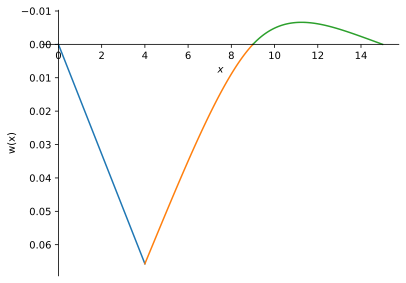

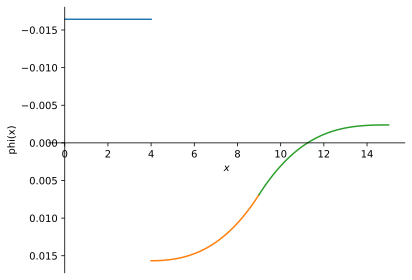

In [9]:
plot([w1_oplossing, w2_oplossing, w3_oplossing], [(0, 4), (4, 9), (9, 15)], 'w(x)')
plot([phi1_oplossing, phi2_oplossing, phi3_oplossing], [(0, 4), (4, 9), (9, 15)], 'phi(x)')


In [11]:
eq13 = sym.Eq(phi3_oplossing, 0)
display(sym.solve(eq13, x))
max_opbolling_x= sym.solve(eq13, x)[2] # m
display(max_opbolling_x.evalf())
max_opbolling = w3_oplossing.subs(x, max_opbolling_x) # m
display(max_opbolling)
display(max_opbolling.evalf())

⎡                                                                    _________ ↪
⎢                                                   ⎛  1   √3⋅ⅈ⎞    ╱ √4338082 ↪
⎢                                                   ⎜- ─ - ────⎟⋅3 ╱  ──────── ↪
⎢547                       49                       ⎝  2    2  ⎠ ╲╱       8    ↪
⎢─── - ────────────────────────────────────────── - ────────────────────────── ↪
⎢36                         _____________________                     3        ↪
⎢          ⎛  1   √3⋅ⅈ⎞    ╱ √43380821   1422665                               ↪
⎢      432⋅⎜- ─ - ────⎟⋅3 ╱  ───────── + ───────                               ↪
⎣          ⎝  2    2  ⎠ ╲╱       8        1728                                 ↪

↪ ____________                         _____________________                   ↪
↪ 1   1422665         ⎛  1   √3⋅ⅈ⎞    ╱ √43380821   1422665                    ↪
↪ ─ + ───────         ⎜- ─ + ────⎟⋅3 ╱  ───────── + ───────                    ↪
↪      1728     547   ⎝  2 

11.2486581757475

                                                                               ↪
                ⎛      _____________________                                   ↪
                ⎜     ╱ √43380821   1422665                                    ↪
                ⎜  3 ╱  ───────── + ───────                                    ↪
                ⎜  ╲╱       8        1728                   49                 ↪
            547⋅⎜- ───────────────────────── - ───────────────────────────── + ↪
                ⎜              3                       _____________________   ↪
                ⎜                                     ╱ √43380821   1422665    ↪
                ⎜                              432⋅3 ╱  ───────── + ───────    ↪
  5752967       ⎝                                  ╲╱       8        1728      ↪
- ─────── - ────────────────────────────────────────────────────────────────── ↪
  3686400                                    921600                            ↪
                            

-0.00660381480954193

::::{admonition-end}
::::